# XMLD Ptycho notebook
First generate code to simulate the speckle pattern for a Neel texture for several given probes (of different linear polarisations).
* The sample (object) is now represented by pixels each of which is a complex Jones Matrix. This Jones matrix is able to act on different polarisations differently
* The Jones Matrix is constructed from a Neel field (parametrised by $\theta$ and $\phi$)
* Several probes are now needed, each with a different Jones vector
* A tensor of diffraction patterns are now collected of shape 

In [6]:
from vector_ptycho.utils import *
import numpy as np
import matplotlib.pyplot as plt
import torch


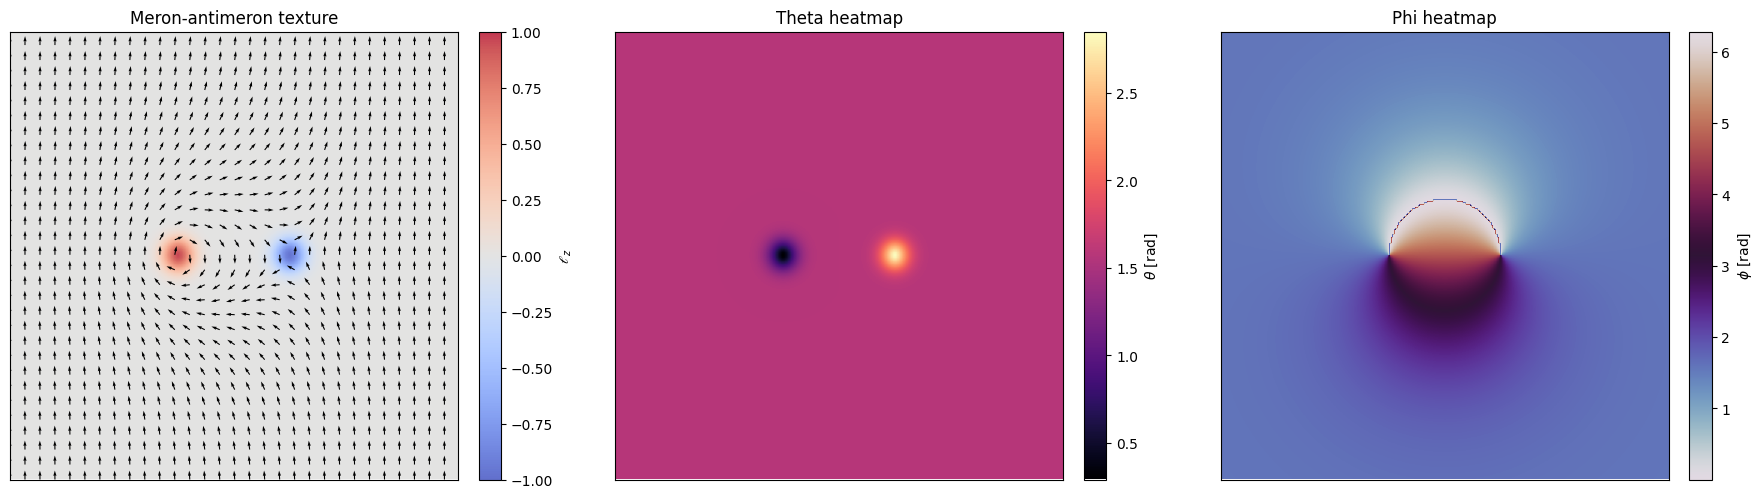

theta/phi shape: (300, 300)


In [15]:
def make_meron_antimeron_theta_phi(
    Nx=300,
    Ny=300,
    Lx=10.0,
    Ly=None,
    r1=(-2.5, 0.0),
    r2=(2.5, 0.0),
    sigma=0.5,
    m0=0.95,
    phi0=np.pi / 2,
    align_sigma=5.0,
    quiver_step=10,
    plot=True,
    save_path='Meron-anti-meron-quiver.svg',
    export_path=None,
    return_torch=True,
    out_device=None,
):
    """
    Build a meron-antimeron texture and return (theta, phi) suitable for NeelObject.build_jones().

    Returns:
        theta, phi with shape (Ny, Nx). By default returns torch tensors.
        mx, My, Mz arrays of shape (Ny, Nx) for optional further analysis or plotting.
    """
    if out_device is None:
        out_device = "cuda" if torch.cuda.is_available() else "cpu"

    if Ly is None:
        Ly = Lx

    r1 = np.asarray(r1, dtype=np.float32)
    r2 = np.asarray(r2, dtype=np.float32)

    # --- Grid ---
    x = np.linspace(-Lx, Lx, Nx, dtype=np.float32)
    y = np.linspace(-Ly, Ly, Ny, dtype=np.float32)
    X, Y = np.meshgrid(x, y, indexing='xy')

    def angle_vortex(Xg, Yg, r0):
        return np.arctan2(Yg - r0[1], Xg - r0[0])

    def gauss_core(Xg, Yg, r0, s):
        return np.exp(-((Xg - r0[0])**2 + (Yg - r0[1])**2) / (2.0 * s**2))

    def gauss_alignment_to_background(Xg, Yg, s):
        return np.exp(-(Xg**2 + Yg**2) / (2.0 * s**2))

    # --- Meron-antimeron texture ---
    phi_inplane = angle_vortex(X, Y, r1) - angle_vortex(X, Y, r2) + phi0
    Mz = m0 * (gauss_core(X, Y, r1, sigma) - gauss_core(X, Y, r2, sigma))
    Mz = np.clip(Mz, -0.9999, 0.9999)

    Minplane = np.sqrt(np.maximum(1.0 - Mz**2, 0.0))
    Mx = Minplane * np.cos(phi_inplane) * gauss_alignment_to_background(X, Y, s=align_sigma)
    My = Minplane * np.sin(phi_inplane)

    # Optional renormalization to keep spin vectors numerically bounded.
    norm3 = np.sqrt(Mx**2 + My**2 + Mz**2)
    norm3[norm3 == 0] = 1.0
    Mx = Mx / norm3
    My = My / norm3
    Mz = Mz / norm3

    # Convert to spherical angles used by NeelObject.build_jones(theta, phi)
    # theta: polar angle from +z, phi: azimuth in x-y plane.
    theta_np = np.arccos(np.clip(Mz, -1.0, 1.0)).astype(np.float32)
    phi_np = np.mod(np.arctan2(My, Mx), 2.0 * np.pi).astype(np.float32)

    if export_path is not None:
        np.savez(export_path, theta=theta_np, phi=phi_np)

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Panel 1: original style plot (Mz + in-plane quiver)
        im0 = axes[0].imshow(
            Mz,
            extent=[-Lx, Lx, -Ly, Ly],
            origin='lower',
            alpha=0.8,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
        )
        cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
        cbar0.set_label(r'$\mathscr{l}_z$')

        xs = X[::quiver_step, ::quiver_step]
        ys = Y[::quiver_step, ::quiver_step]
        mxs = Mx[::quiver_step, ::quiver_step]
        mys = My[::quiver_step, ::quiver_step]

        qnorm = np.sqrt(mxs**2 + mys**2)
        qnorm[qnorm == 0] = 1.0
        axes[0].quiver(xs, ys, mxs / qnorm, mys / qnorm, scale=50)
        axes[0].set_title('Meron-antimeron texture')
        axes[0].set_xticks([])
        axes[0].set_yticks([])

        # Panel 2: theta heatmap
        im1 = axes[1].imshow(theta_np, extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='magma')
        cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
        cbar1.set_label(r'$\theta$ [rad]')
        axes[1].set_title('Theta heatmap')
        axes[1].set_xticks([])
        axes[1].set_yticks([])

        # Panel 3: phi heatmap
        im2 = axes[2].imshow(phi_np, extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='twilight')
        cbar2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
        cbar2.set_label(r'$\phi$ [rad]')
        axes[2].set_title('Phi heatmap')
        axes[2].set_xticks([])
        axes[2].set_yticks([])

        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=500, bbox_inches='tight')
        plt.show()

    if return_torch:
        theta = torch.tensor(theta_np, dtype=torch.float32, device=out_device)
        phi = torch.tensor(phi_np, dtype=torch.float32, device=out_device)
        return theta, phi, Mx, My, Mz

    return theta_np, phi_np, Mx, My, Mz


# Example call
theta, phi, Mx, My, Mz = make_meron_antimeron_theta_phi(
    Nx=300,
    Ny=300,
    Lx=10.0,
    plot=True,
    export_path='theta_phi_meron_antimeron.npz',
    return_torch=True,
    out_device=device,
)
print('theta/phi shape:', tuple(theta.shape))

In [16]:
print('theta range: [{:.3f}, {:.3f}]'.format(theta.min().item(), theta.max().item()))
print('phi range: [{:.3f}, {:.3f}]'.format(phi.min().item(), phi.max().item()))

print('Mx range: [{:.3f}, {:.3f}]'.format(Mx.min().item(), Mx.max().item()))
print('My range: [{:.3f}, {:.3f}]'.format(My.min().item(), My.max().item()))
print('Mz range: [{:.3f}, {:.3f}]'.format(Mz.min().item(), Mz.max().item()))

theta range: [0.291, 2.851]
phi range: [0.001, 6.282]
Mx range: [-1.000, 1.000]
My range: [-1.000, 1.000]
Mz range: [-0.958, 0.958]


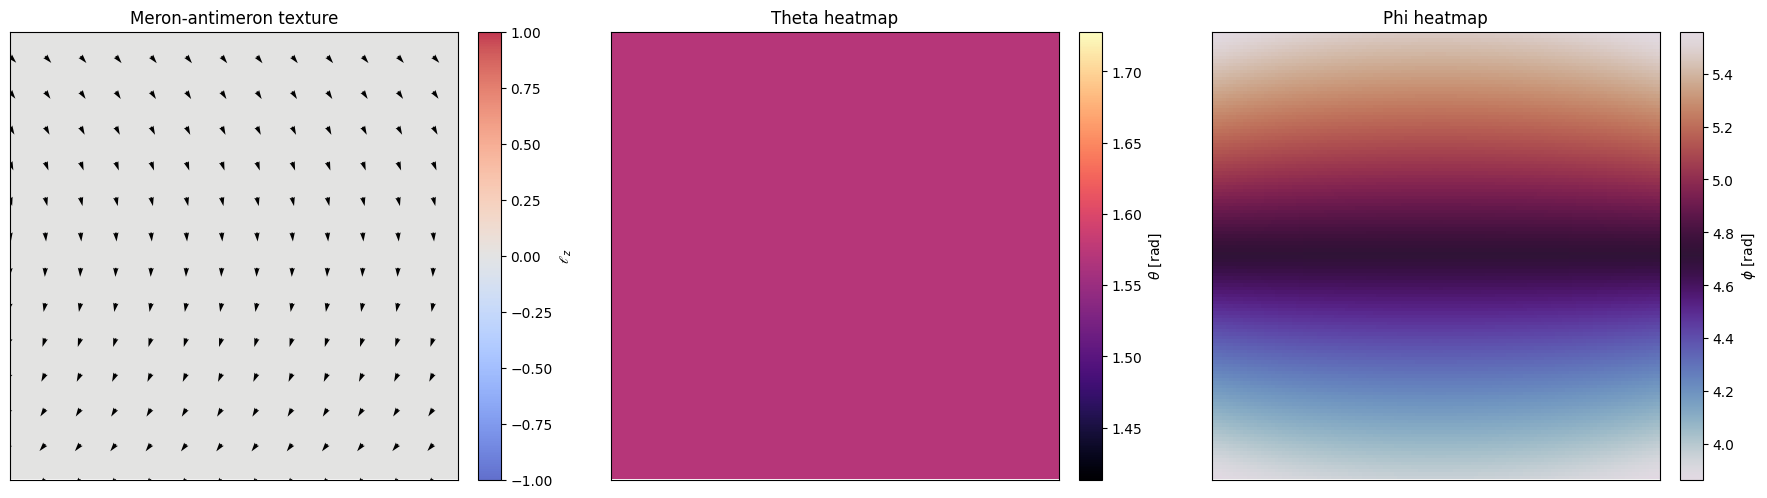

Simulated data shape: torch.Size([3, 5, 128, 128])
Recovered theta shape: torch.Size([128, 128])


In [10]:
# =========================
# Example usage
# =========================
H, W = 128, 128

# Build theta, phi from meron-antimeron generator (returns torch tensors)
theta, phi = make_meron_antimeron_theta_phi(
    Nx=W,
    Ny=H,
    Lx=1.0,
    Ly=1.0,
    sigma=0.12,
    m0=0.95,
    plot=True,
    save_path=None,
    export_path=None,
    return_torch=True,
    out_device=device,
)

# Physical XMLD/Jones constants
C = torch.tensor(1.0 + 0.0j, dtype=cdtype, device=device)
A1 = torch.tensor(0.15 + 0.05j, dtype=cdtype, device=device)
A2 = torch.tensor(0.10 + 0.03j, dtype=cdtype, device=device)

# Build Jones object from theta, phi
neel = NeelObject(C, A1, A2)
J = neel.build_jones(theta, phi)
obj = JonesObject(J)

# Grid for probe definition
x = torch.linspace(-1, 1, H, device=device)
X, Y = torch.meshgrid(x, x, indexing='ij')

# Probe amplitude
amp = torch.exp(-(X**2 + Y**2)/0.1).to(cdtype)

# Multiple polarisation probes
probes = [
    Probe(amp, torch.tensor([1+0j, 0+0j], dtype=cdtype, device=device)),  # H
    Probe(amp, torch.tensor([0+0j, 1+0j], dtype=cdtype, device=device)),  # V
    Probe(amp, torch.tensor([1/np.sqrt(2), 1/np.sqrt(2)], dtype=cdtype, device=device)),  # 45 deg
]

# Scan positions
positions = [
    (-10, -10),
    (-5, 0),
    (0, 0),
    (5, 5),
    (10, 10),
]
scan = ScanTrajectory(positions)

# Forward model
model = ForwardModel(obj, Propagator(), Detector())

I_sim = model.simulate_all(probes, scan)
print('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)

# =========================
# Convert back Jones -> Neel
# =========================
theta_rec, phi_rec = jones_to_neel(J)
print('Recovered theta shape:', theta_rec.shape)